In [7]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
import gc
from concurrent.futures import ProcessPoolExecutor, as_completed

# ===================== 配置 =====================
CACHE_DIR = "/root/autodl-tmp/figure_separate"
BREAKPOINT_FILE = os.path.join(CACHE_DIR, "breakpoint_progress.json")
os.makedirs(CACHE_DIR, exist_ok=True)
CSV_PATH = "/root/autodl-tmp/日个股数据2.0.csv"

DATE_COL = "Trddt"
STOCK_COL = "Stkcd"
OPEN_COL = "Opnprc"
HIGH_COL = "Hiprc"
LOW_COL = "Loprc"
CLOSE_COL = "Clsprc"
VOL_COL = "Dnshrtrd"

MAX_WORKERS = 16
IMAGE_SIZE = 224
WINDOW = 60        # 过去60天K线（画图）
HORIZON = 7        # ✅ 未来7天收益率（预测目标）

# ===================== 极速绘图 =====================
def normalize_series(s):
    s = np.asarray(s)
    min_val = s.min()
    max_val = s.max()
    scale = max(max_val - min_val, 1e-6)
    return (s - min_val) / scale

def draw_candle(open_, high, low, close, size=IMAGE_SIZE):
    img = np.ones((size, size, 3), dtype=np.uint8) * 255
    n = len(open_)
    step = size / n
    w = max(int(step * 0.6), 1)
    for i in range(n):
        o, h, l, c = open_[i], high[i], low[i], close[i]
        is_green = c >= o
        x = int(i * step)
        y_h = int((1 - h) * (size - 8)) + 4
        y_l = int((1 - l) * (size - 8)) + 4
        y_o = int((1 - o) * (size - 8)) + 4
        y_c = int((1 - c) * (size - 8)) + 4
        color = [0, 200, 0] if is_green else [200, 0, 0]
        img[y_h:y_l+1, max(x-1,0):min(x+2, size)] = color
        y1, y2 = min(y_o, y_c), max(y_o, y_c)
        if y2 - y1 < 2: y2 = y1 + 2
        x1 = max(x - w//2, 0)
        x2 = min(x + w//2 +1, size)
        img[y1:y2, x1:x2] = color
    return img

def draw_candle_volume(open_, high, low, close, vol, size=IMAGE_SIZE):
    img = np.ones((size, size, 3), dtype=np.uint8) * 255
    n = len(open_)
    step = size / n
    w = max(int(step * 0.6), 1)
    vol_height = size // 5
    for i in range(n):
        o, h, l, c, v = open_[i], high[i], low[i], close[i], vol[i]
        is_green = c >= o
        color = [0, 200, 0] if is_green else [200, 0, 0]
        x = int(i * step)
        y_h = int((1 - h) * (size - vol_height - 8)) + 4
        y_l = int((1 - l) * (size - vol_height - 8)) + 4
        y_o = int((1 - o) * (size - vol_height - 8)) + 4
        y_c = int((1 - c) * (size - vol_height - 8)) + 4
        img[y_h:y_l+1, max(x-1,0):min(x+2, size)] = color
        y1, y2 = min(y_o, y_c), max(y_o, y_c)
        if y2 - y1 < 2: y2 = y1 + 2
        x1 = max(x - w//2,0)
        x2 = min(x + w//2+1, size)
        img[y1:y2, x1:x2] = color
        v_h = size - int(v * (vol_height -4)) -2
        img[v_h:size-2, x1:x2] = color
    return img

def render_c(pr):
    o = normalize_series(pr['open'])
    h = normalize_series(pr['high'])
    l = normalize_series(pr['low'])
    c = normalize_series(pr['close'])
    return draw_candle(o, h, l, c)

def render_cv(pr):
    o = normalize_series(pr['open'])
    h = normalize_series(pr['high'])
    l = normalize_series(pr['low'])
    c = normalize_series(pr['close'])
    v = normalize_series(pr['volume'])
    return draw_candle_volume(o, h, l, c, v)

# ===================== 超快读CSV =====================
def load_clean_csv():
    print("⏳ 正在加载CSV文件...")
    df = pd.read_csv(
        CSV_PATH,
        dtype={STOCK_COL: str, OPEN_COL: np.float32, HIGH_COL: np.float32,
               LOW_COL: np.float32, CLOSE_COL: np.float32, VOL_COL: np.float32},
        usecols=[DATE_COL, STOCK_COL, OPEN_COL, HIGH_COL, LOW_COL, CLOSE_COL, VOL_COL],
        low_memory=False
    )
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    df = df.dropna(subset=[DATE_COL])
    df = df.sort_values([STOCK_COL, DATE_COL]).reset_index(drop=True)
    gc.collect()
    return df

# ===================== ✅ 标签：未来7天收益率 =====================
def get_labels(close):
    n = len(close)
    ret = np.full(n, np.nan)
    for i in range(n - HORIZON):
        # 未来7天收益率 = (close[i+7] / close[i]) - 1
        ret[i] = close[i + HORIZON] / close[i] - 1
    return ret

def load_bp():
    if os.path.exists(BREAKPOINT_FILE):
        with open(BREAKPOINT_FILE) as f:
            return json.load(f)
    return {"done": [], "total": 0}

def save_bp(done, total):
    with open(BREAKPOINT_FILE, 'w') as f:
        json.dump({"done": done, "total": total}, f)

# ===================== 业务 =====================
def process_one(sid, g):
    try:
        g = g.sort_values(DATE_COL).reset_index(drop=True)
        close = g[CLOSE_COL].values
        ret = get_labels(close)
        n = len(g)
        valid_ends = [end for end in range(WINDOW-1, n-HORIZON) if not np.isnan(ret[end])]
        total_windows = len(valid_ends)
        if total_windows == 0:
            return sid, 0

        imgs_c, imgs_cv, imgs_heat, labels = [], [], [], []
        for end in valid_ends:
            win = g.iloc[end-WINDOW+1 : end+1]
            pr = {
                'open': win[OPEN_COL].values, 'high': win[HIGH_COL].values,
                'low': win[LOW_COL].values, 'close': win[CLOSE_COL].values,
                'volume': win[VOL_COL].values
            }
            imgs_c.append(render_c(pr))
            imgs_cv.append(render_cv(pr))
            imgs_heat.append(render_c(pr))
            labels.append(ret[end])

        np.savez_compressed(f"{CACHE_DIR}/{sid}.npz", c=imgs_c, cv=imgs_cv, heat=imgs_heat, label=labels)
        return sid, total_windows * 3
    except Exception:
        return sid, 0

# ===================== 主程序 =====================
if __name__ == "__main__":
    df = load_clean_csv()

    progress = load_bp()
    done = set(progress["done"])
    total = progress["total"]
    groups = [(sid, g) for sid, g in df.groupby(STOCK_COL) if sid not in done]
    del df
    gc.collect()

    total_stock = len(groups)
    print(f"\n📊 总股票数：{total_stock}")
    print(f"🚀 开启多进程极速生成（CPU核心数：{MAX_WORKERS}）...\n")

    with ProcessPoolExecutor(MAX_WORKERS) as exe:
        futures = [exe.submit(process_one, sid, g) for sid, g in groups]
        for f in tqdm(as_completed(futures), total=total_stock, desc="整体进度", ncols=100):
            sid, cnt = f.result()
            done.add(sid)
            total += cnt
            save_bp(list(done), total)

    print(f"\n🎉 完成！总样本：{total}")

⏳ 正在加载CSV文件...

📊 总股票数：270
🚀 开启多进程极速生成（CPU核心数：16）...



整体进度: 100%|███████████████████████████████████████████████████| 270/270 [01:37<00:00,  2.77it/s]


🎉 完成！总样本：927231


📦 1 generated 1146 images
🖼 Image shape: (224, 224, 3)
📈 7-day return: -0.0698


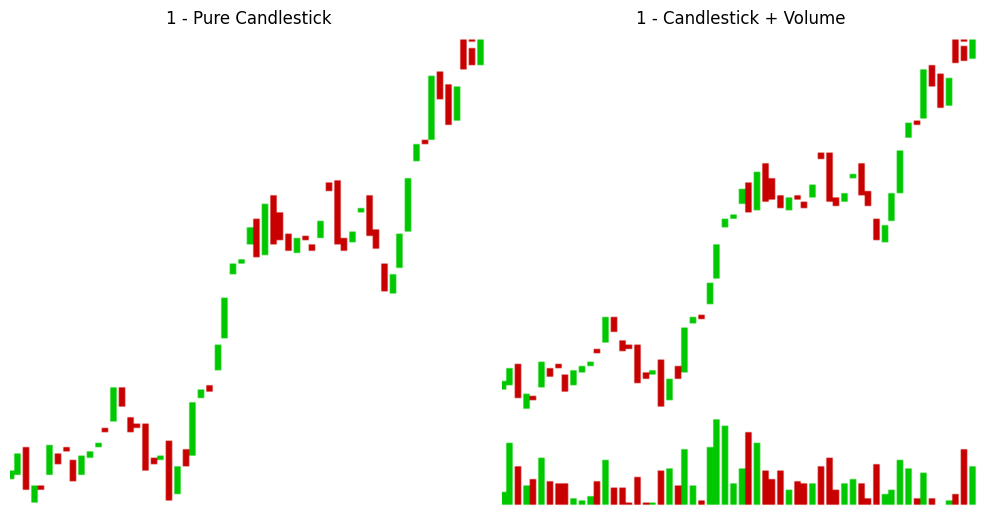

In [10]:
import numpy as np
import matplotlib.pyplot as plt

STOCK_CODE = "1"  # 你实际的股票代码
npz_path = f"/root/autodl-tmp/figure_separate/{STOCK_CODE}.npz"

data = np.load(npz_path)
imgs_c = data['c']
imgs_cv = data['cv']
labels = data['label']

print(f"📦 {STOCK_CODE} generated {len(imgs_c)} images")
print(f"🖼 Image shape: {imgs_c[0].shape}")
print(f"📈 7-day return: {labels[0]:.4f}")

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(imgs_c[0])
plt.title(f"{STOCK_CODE} - Pure Candlestick")  # 纯英文标题
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgs_cv[0])
plt.title(f"{STOCK_CODE} - Candlestick + Volume")  # 纯英文标题
plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import gc

# ===================== 配置 =====================
CACHE_DIR = "/root/autodl-tmp/figure_separate"
BREAKPOINT_FILE = os.path.join(CACHE_DIR, "breakpoint_progress.json")
os.makedirs(CACHE_DIR, exist_ok=True)
CSV_PATH = "/root/autodl-tmp/日个股数据2.0.csv"

DATE_COL = "Trddt"
STOCK_COL = "Stkcd"
OPEN_COL = "Opnprc"
HIGH_COL = "Hiprc"
LOW_COL = "Loprc"
CLOSE_COL = "Clsprc"
VOL_COL = "Dnshrtrd"

IMAGE_SIZE = 224
WINDOW = 60
HORIZON = 7

# ===================== 极速绘图 =====================
def normalize_series(s):
    s = np.asarray(s, dtype=np.float32)
    min_val = s.min()
    max_val = s.max()
    scale = max(max_val - min_val, 1e-6)
    return (s - min_val) / scale

def draw_candle(open_, high, low, close, size=IMAGE_SIZE):
    img = np.ones((size, size, 3), dtype=np.uint8) * 255
    n = len(open_)
    step = size / n
    w = max(int(step * 0.6), 1)
    for i in range(n):
        o, h, l, c = open_[i], high[i], low[i], close[i]
        is_green = c >= o
        x = int(i * step)
        y_h = int((1 - h) * (size - 8)) + 4
        y_l = int((1 - l) * (size - 8)) + 4
        y_o = int((1 - o) * (size - 8)) + 4
        y_c = int((1 - c) * (size - 8)) + 4
        color = [0, 200, 0] if is_green else [200, 0, 0]
        img[y_h:y_l+1, max(x-1,0):min(x+2, size)] = color
        y1, y2 = min(y_o, y_c), max(y_o, y_c)
        if y2 - y1 < 2: y2 = y1 + 2
        x1 = max(x - w//2, 0)
        x2 = min(x + w//2 +1, size)
        img[y1:y2, x1:x2] = color
    return img

def draw_candle_volume(open_, high, low, close, vol, size=IMAGE_SIZE):
    img = np.ones((size, size, 3), dtype=np.uint8) * 255
    n = len(open_)
    step = size / n
    w = max(int(step * 0.6), 1)
    vol_height = size // 5
    for i in range(n):
        o, h, l, c, v = open_[i], high[i], low[i], close[i], vol[i]
        is_green = c >= o
        color = [0, 200, 0] if is_green else [200, 0, 0]
        x = int(i * step)
        y_h = int((1 - h) * (size - vol_height - 8)) + 4
        y_l = int((1 - l) * (size - vol_height - 8)) + 4
        y_o = int((1 - o) * (size - vol_height - 8)) + 4
        y_c = int((1 - c) * (size - vol_height - 8)) + 4
        img[y_h:y_l+1, max(x-1,0):min(x+2, size)] = color
        y1, y2 = min(y_o, y_c), max(y_o, y_c)
        if y2 - y1 < 2: y2 = y1 + 2
        x1 = max(x - w//2,0)
        x2 = min(x + w//2+1, size)
        img[y1:y2, x1:x2] = color
        v_h = size - int(v * (vol_height -4)) -2
        img[v_h:size-2, x1:x2] = color
    return img

def render_c(pr):
    o = normalize_series(pr['open'])
    h = normalize_series(pr['high'])
    l = normalize_series(pr['low'])
    c = normalize_series(pr['close'])
    return draw_candle(o, h, l, c)

def render_cv(pr):
    o = normalize_series(pr['open'])
    h = normalize_series(pr['high'])
    l = normalize_series(pr['low'])
    c = normalize_series(pr['close'])
    v = normalize_series(pr['volume'])
    return draw_candle_volume(o, h, l, c, v)

# ===================== 读数据 =====================
def load_clean_csv():
    print("⏳ 加载CSV...")
    df = pd.read_csv(
        CSV_PATH,
        dtype={STOCK_COL: str, OPEN_COL: np.float32, HIGH_COL: np.float32,
               LOW_COL: np.float32, CLOSE_COL: np.float32, VOL_COL: np.float32},
        usecols=[DATE_COL, STOCK_COL, OPEN_COL, HIGH_COL, LOW_COL, CLOSE_COL, VOL_COL],
        low_memory=False
    )
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    df = df.dropna(subset=[DATE_COL])
    df = df.sort_values([STOCK_COL, DATE_COL]).reset_index(drop=True)
    gc.collect()
    return df

# ===================== 标签 =====================
def get_labels(close):
    n = len(close)
    ret = np.full(n, np.nan, dtype=np.float32)
    for i in range(n - HORIZON):
        ret[i] = close[i + HORIZON] / close[i] - 1
    return ret

# ===================== 真实检查 =====================
def get_real_existing_stocks():
    if not os.path.exists(CACHE_DIR):
        return set()
    files = os.listdir(CACHE_DIR)
    return set([f.replace(".npz","") for f in files if f.endswith(".npz")])

# ===================== 【稳定】单进程处理 =====================
if __name__ == "__main__":
    os.makedirs(CACHE_DIR, exist_ok=True)
    df = load_clean_csv()
    real_done = get_real_existing_stocks()

    print(f"📂 已生成：{len(real_done)} 只")
    groups = list(df.groupby(STOCK_COL))
    todo = [g for g in groups if g[0] not in real_done]
    print(f"📊 待生成：{len(todo)} 只")

    # 单进程 + 逐一生成 = 100% 不损坏
    for sid, g in tqdm(todo, desc="总进度"):
        try:
            g = g.sort_values(DATE_COL).reset_index(drop=True)
            close = g[CLOSE_COL].values.astype(np.float32)
            ret = get_labels(close)
            n = len(g)
            valid_ends = [end for end in range(WINDOW-1, n-HORIZON) if not np.isnan(ret[end])]
            if not valid_ends:
                continue

            imgs_c, imgs_cv, labels = [], [], []
            for end in valid_ends:
                win = g.iloc[end-WINDOW+1 : end+1]
                pr = {
                    'open': win[OPEN_COL].values, 'high': win[HIGH_COL].values,
                    'low': win[LOW_COL].values, 'close': win[CLOSE_COL].values,
                    'volume': win[VOL_COL].values
                }
                imgs_c.append(render_c(pr))
                imgs_cv.append(render_cv(pr))
                labels.append(ret[end])

            # 保存（单进程绝对不会坏）
            np.savez_compressed(
                f"{CACHE_DIR}/{sid}.npz",
                c=imgs_c, cv=imgs_cv, heat=imgs_c, label=labels
            )
            gc.collect()
        except:
            continue

    final = len(get_real_existing_stocks())
    print(f"\n🎉 完成！总股票数：{final}")

⏳ 加载CSV...
📂 已生成：0 只
📊 待生成：270 只


总进度: 100%|██████████| 270/270 [26:14<00:00,  5.83s/it]


🎉 完成！总股票数：270


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

STOCK_CODE = "1"  # 你实际的股票代码
npz_path = f"/root/autodl-tmp/figure_separate/{STOCK_CODE}.npz"

data = np.load(npz_path)
imgs_c = data['c']
imgs_cv = data['cv']
labels = data['label']

print(f"📦 {STOCK_CODE} generated {len(imgs_c)} images")
print(f"🖼 Image shape: {imgs_c[0].shape}")
print(f"📈 7-day return: {labels[0]:.4f}")

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(imgs_c[0])
plt.title(f"{STOCK_CODE} - Pure Candlestick")  # 纯英文标题
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgs_cv[0])
plt.title(f"{STOCK_CODE} - Candlestick + Volume")  # 纯英文标题
plt.axis('off')

plt.tight_layout()
plt.show()